In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy



In [ ]:
train_dir = r'D:\bird_classification\BIRDS\TRAIN'
valid_dir = r'D:\bird_classification\BIRDS\TEST'


In [ ]:
image_size = (256, 256)
batch_size = 16
num_classes = 62

In [ ]:
def load_images_from_folder(folder):
    images = []
    labels = []

    # Iterate over each bird species (subfolder) in the main folder
    for label in os.listdir(folder):
        species_folder = os.path.join(folder, label)

        # Check if the species_folder is indeed a directory
        if os.path.isdir(species_folder):
            images_folder = os.path.join(species_folder, 'images')

            # Check if the images_folder exists and is a directory
            if os.path.isdir(images_folder):
                # Iterate over each image file in the images subfolder
                for img_file in os.listdir(images_folder):
                    img_path = os.path.join(images_folder, img_file)

                    images.append(img_path)
                    labels.append(label)

    return images, labels


In [ ]:
images, labels = load_images_from_folder(train_dir)
valid_images, valid_labels = load_images_from_folder(valid_dir)

Number of available images: 45085


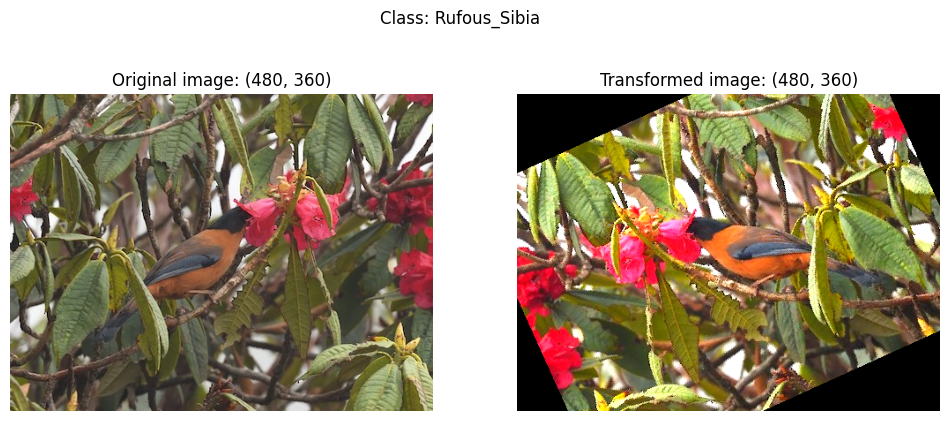

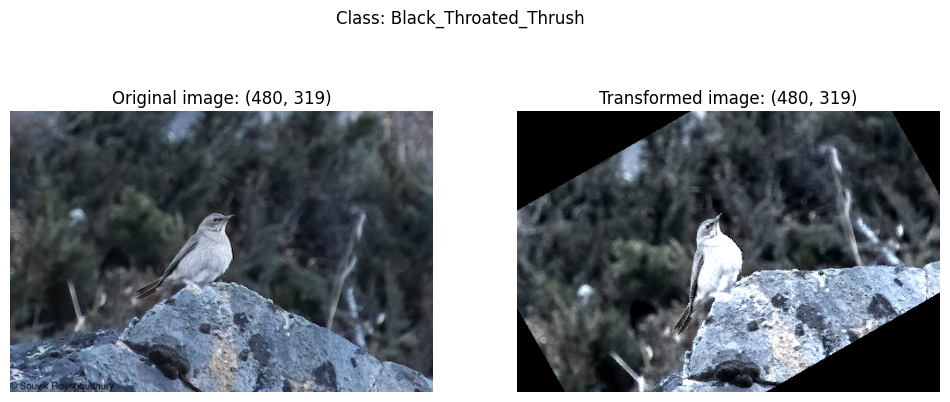

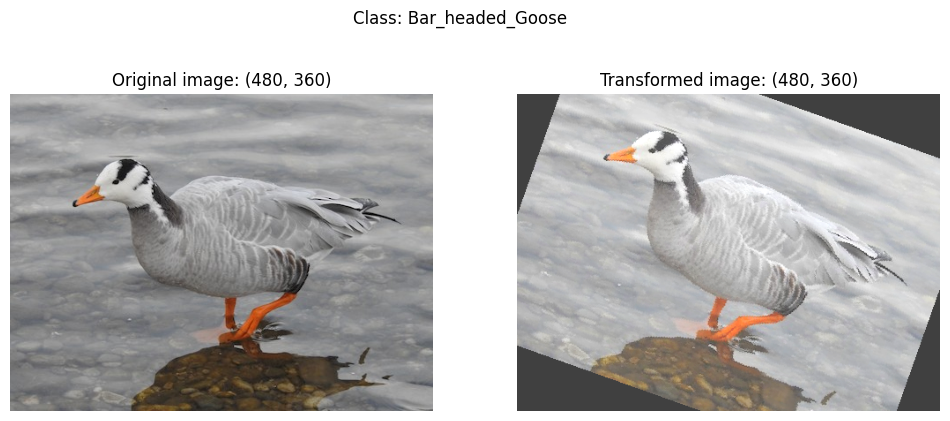

In [ ]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image # type: ignore
from torchvision import transforms

# Define the directory path
IMAGE_PATH = r'D:\bird_classification\BIRDS\TRAIN'

# Gather image paths
image_path_list = list(Path(IMAGE_PATH).glob("*/*.[jp][pn]*"))

# Check number of available images
num_images = len(image_path_list)
print(f"Number of available images: {num_images}")

# Transformation Function
def apply_random_augmentation(img):
    """Apply random transformations to an image."""
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        transforms.ToTensor()
    ])
    transformed_img = transform(img)
    # Convert tensor back to PIL Image for displaying
    return transforms.ToPILImage()(transformed_img)

# Function to plot original and transformed images
def plot_transformed_image(img_path, transform, n=3, seed=42):
    """Selects random images and plots them alongside their transformed counterparts."""
    random.seed(seed)  # Ensure reproducibility

    # Ensure n is within a valid range
    n = min(n, len(img_path))

    random_image_paths = random.sample(img_path, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as img:
            fig, ax = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)

            # Plot the original image
            ax[0].imshow(img)
            ax[0].set_title(f"Original image: {img.size}")
            ax[0].axis(False)

            # Apply the transformation
            transformed_image = transform(img)
            # Ensure transformed_image is a PIL Image
            if not isinstance(transformed_image, Image.Image):
                transformed_image = transforms.ToPILImage()(transformed_image)

            # Plot the transformed image
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed image: {transformed_image.size}")
            ax[1].axis(False)

            # Display class name from the parent directory of the 'images' folder
            fig.suptitle(f"Class: {image_path.parent.stem}")
            plt.show()

# Plot some transformed images
plot_transformed_image(
    img_path=image_path_list,
    transform=apply_random_augmentation,
    n=3,  # Number of images to plot
    seed=42
)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Specify the paths to the training and validation data directories
train_directory = r'D:\bird_classification\BIRDS\TRAIN'
validation_directory = r'D:\bird_classification\BIRDS\TEST'

# Set the image size and batch size
image_size = (256, 256)
batch_size = 16

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    train_directory,
    target_size=(256, 256),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    validation_directory,
    target_size=(256, 256),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 45084 images belonging to 62 classes.
Found 6853 images belonging to 62 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Define the number of classes
num_classes = 62

# Create the VGG16 base model with pre-trained weights
base_model = VGG16(
    include_top=False,
    input_shape=(256, 256, 3),
    weights='imagenet'
)

# Add custom classification layers on top
model_vgg16 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    # Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_vgg16.build(input_shape=(None, 256, 256, 3))
model_vgg16.summary()

# Print the model summary
model_vgg16.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 62)                31806     
                                                                 
Total params: 14,746,494
Trainable params: 14,746,494
Non-trainable params: 0
_________________________________________________________________
Model: "sequential"
_________________________________________________________________
 Layer (type)           

In [ ]:
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy
model_vgg16.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)



In [ ]:
# Train the model
epochs = 20
callbacks = EarlyStopping(monitor='loss', patience=3)
vgg16_history = model_vgg16.fit(
    callbacks=[callbacks],
    x = train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

Epoch 1/20
2818/2818 [==============================] - 1913s 661ms/step - loss: 4.1021 - accuracy: 0.0240 - val_loss: 3.9450 - val_accuracy: 0.0566
Epoch 2/20
2818/2818 [==============================] - 1603s 569ms/step - loss: 3.7367 - accuracy: 0.0690 - val_loss: 3.5063 - val_accuracy: 0.1160
Epoch 3/20
2818/2818 [==============================] - 1595s 566ms/step - loss: 3.1746 - accuracy: 0.1680 - val_loss: 2.6755 - val_accuracy: 0.2870
Epoch 4/20
2818/2818 [==============================] - 1589s 564ms/step - loss: 2.2972 - accuracy: 0.3713 - val_loss: 2.0424 - val_accuracy: 0.4585
Epoch 5/20
2818/2818 [==============================] - 1608s 570ms/step - loss: 1.6192 - accuracy: 0.5459 - val_loss: 1.5306 - val_accuracy: 0.6104
Epoch 6/20
2818/2818 [==============================] - 1594s 566ms/step - loss: 1.2334 - accuracy: 0.6538 - val_loss: 1.4040 - val_accuracy: 0.6744
Epoch 7/20
2818/2818 [==============================] - 1680s 596ms/step - loss: 1.0110 - accuracy: 0.7125

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model


# Save the model
model_vgg16.save('model_second_vgg16.h5')
print("Model saved")


Model saved


In [ ]:
from tensorflow.keras.models import load_model

# Load the pre-trained or saved model
model_vgg16 = load_model('model_second_vgg16.h5')


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the path to your validation dataset directory
validation_dir = 'D:/bird_classification/BIRDS/TEST'

# Create an instance of ImageDataGenerator
validation_datagen = ImageDataGenerator(rescale=1./255)

# Create the validation data generator
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


Found 6853 images belonging to 62 classes.


In [ ]:
validation_generator.reset()

# Create empty lists to store predicted labels and true labels
predicted_labels = []
true_labels = []

In [ ]:
for i in range(validation_generator.samples // validation_generator.batch_size + 1):
    images, labels = validation_generator.next()
    predictions = model_vgg16.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_labels.extend([key for key, value in validation_generator.class_indices.items() if value == class_idx][0] for class_idx in predicted_classes)
    true_labels.extend([key for key, value in validation_generator.class_indices.items() if value == np.argmax(labels[idx])] for idx in range(len(labels)))


1/1 [==============================] - 3s 3s/step


In [ ]:
true_labels = [label[0] for label in true_labels]

In [ ]:
true_label= [validation_generator.class_indices[label] for label in true_labels]
predicted_label = [validation_generator.class_indices[label] for label in predicted_labels]

In [ ]:
print("Predicted Labels:", predicted_label)
print("True Labels:", true_label)

Predicted Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 58, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 29, 41, 1, 1, 44, 1, 1, 1, 44, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 18, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 12, 2, 2, 2, 2, 2, 7, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 8, 2, 2, 2, 19, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 49, 2, 2, 58, 26, 2, 2, 2, 23, 8, 39, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 53, 58, 2, 2, 2, 2, 2, 2, 2, 19, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Example true labels and predicted labels
true_labels = np.array(true_label)
predicted_labels = np.array(predicted_label)

# Calculate the AUC score for each class
auc_scores = []
for class_index in range(40):
    # Create binary labels for the current class
    binary_true_labels = np.where(true_labels == class_index, 1, 0)
    binary_predicted_labels = np.where(predicted_labels == class_index, 1, 0)

    # Check if only one instance of the class is present
    if np.sum(binary_true_labels) == 1 or np.sum(binary_predicted_labels) == 1:
        auc = np.nan  # Set AUC score as NaN
    else:
        # Calculate the AUC score for the current class
        auc = roc_auc_score(binary_true_labels, binary_predicted_labels)
    auc_scores.append(auc)

# Calculate the average AUC score
average_auc_score = np.nanmean(auc_scores)

print("AUC Scores for each class:")
print(auc_scores)
print("Average AUC Score:", average_auc_score)

AUC Scores for each class:
[0.9799176680017803, 0.9666632539303347, 0.9306920113521091, 0.9269430051813473, 0.896593539173684, 0.946166860526594, 0.8378764278296988, 0.9157600696347729, 0.9666632539303347, 0.9448331171933656, 0.9877215849843587, 0.9566344117791893, 0.9767189502702295, 0.993752154429507, 0.9398852612399665, 0.9640492486237165, 0.88880394429065, 0.9930134928842271, 0.9760364330230898, 0.9138759309814731, 0.8777899119514025, 0.8901979612941351, 0.7675616782390309, 0.9626606588860984, 0.788121091249323, 0.8623102991012228, 0.9499431145478764, 0.9633196746583791, 0.8433914413748954, 0.8797705224799329, 0.8868953862308854, 0.9045590933888805, 0.8935394159143604, 0.8234919335983165, 0.8747787936882465, 0.944074786008839, 0.9392458789852927, 0.9195746876074745, 0.924342105263158, 0.8784238445840656]
Average AUC Score: 0.9169148224578061


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Example true labels and predicted labels
true_labels = np.array(true_label)  # Replace with your true labels
predicted_labels = np.array(predicted_label)  # Replace with your predicted labels

# Calculate the F1 score for each class
f1_scores = []
for class_index in range(40):
    # Create binary labels for the current class
    binary_true_labels = np.where(true_labels == class_index, 1, 0)
    binary_predicted_labels = np.where(predicted_labels == class_index, 1, 0)

    # Calculate the F1 score for the current class
    f1 = f1_score(binary_true_labels, binary_predicted_labels)
    f1_scores.append(f1)

# Calculate the average F1 score
average_f1_score = np.mean(f1_scores)

print("F1 Scores for each class:")
print(f1_scores)
print("Average F1 Score:", average_f1_score)


F1 Scores for each class:
[0.864, 0.9392265193370166, 0.8144796380090498, 0.8235294117647058, 0.7403314917127072, 0.7857142857142857, 0.7342995169082126, 0.765625, 0.9392265193370166, 0.9257142857142857, 0.9194630872483222, 0.8369565217391305, 0.9343065693430657, 0.9707602339181286, 0.891566265060241, 0.8785714285714286, 0.8292682926829268, 0.9171270718232044, 0.9279279279279279, 0.8386167146974063, 0.7752808988764045, 0.7096774193548387, 0.6766917293233082, 0.8478260869565217, 0.5414364640883977, 0.7272727272727273, 0.7699115044247787, 0.9468085106382979, 0.6946107784431138, 0.7804878048780488, 0.7368421052631579, 0.8594377510040161, 0.7487684729064039, 0.7712418300653595, 0.8372093023255814, 0.9142857142857143, 0.925531914893617, 0.7781350482315113, 0.9181494661921709, 0.7555555555555555]
Average F1 Score: 0.8247967966622147


6853


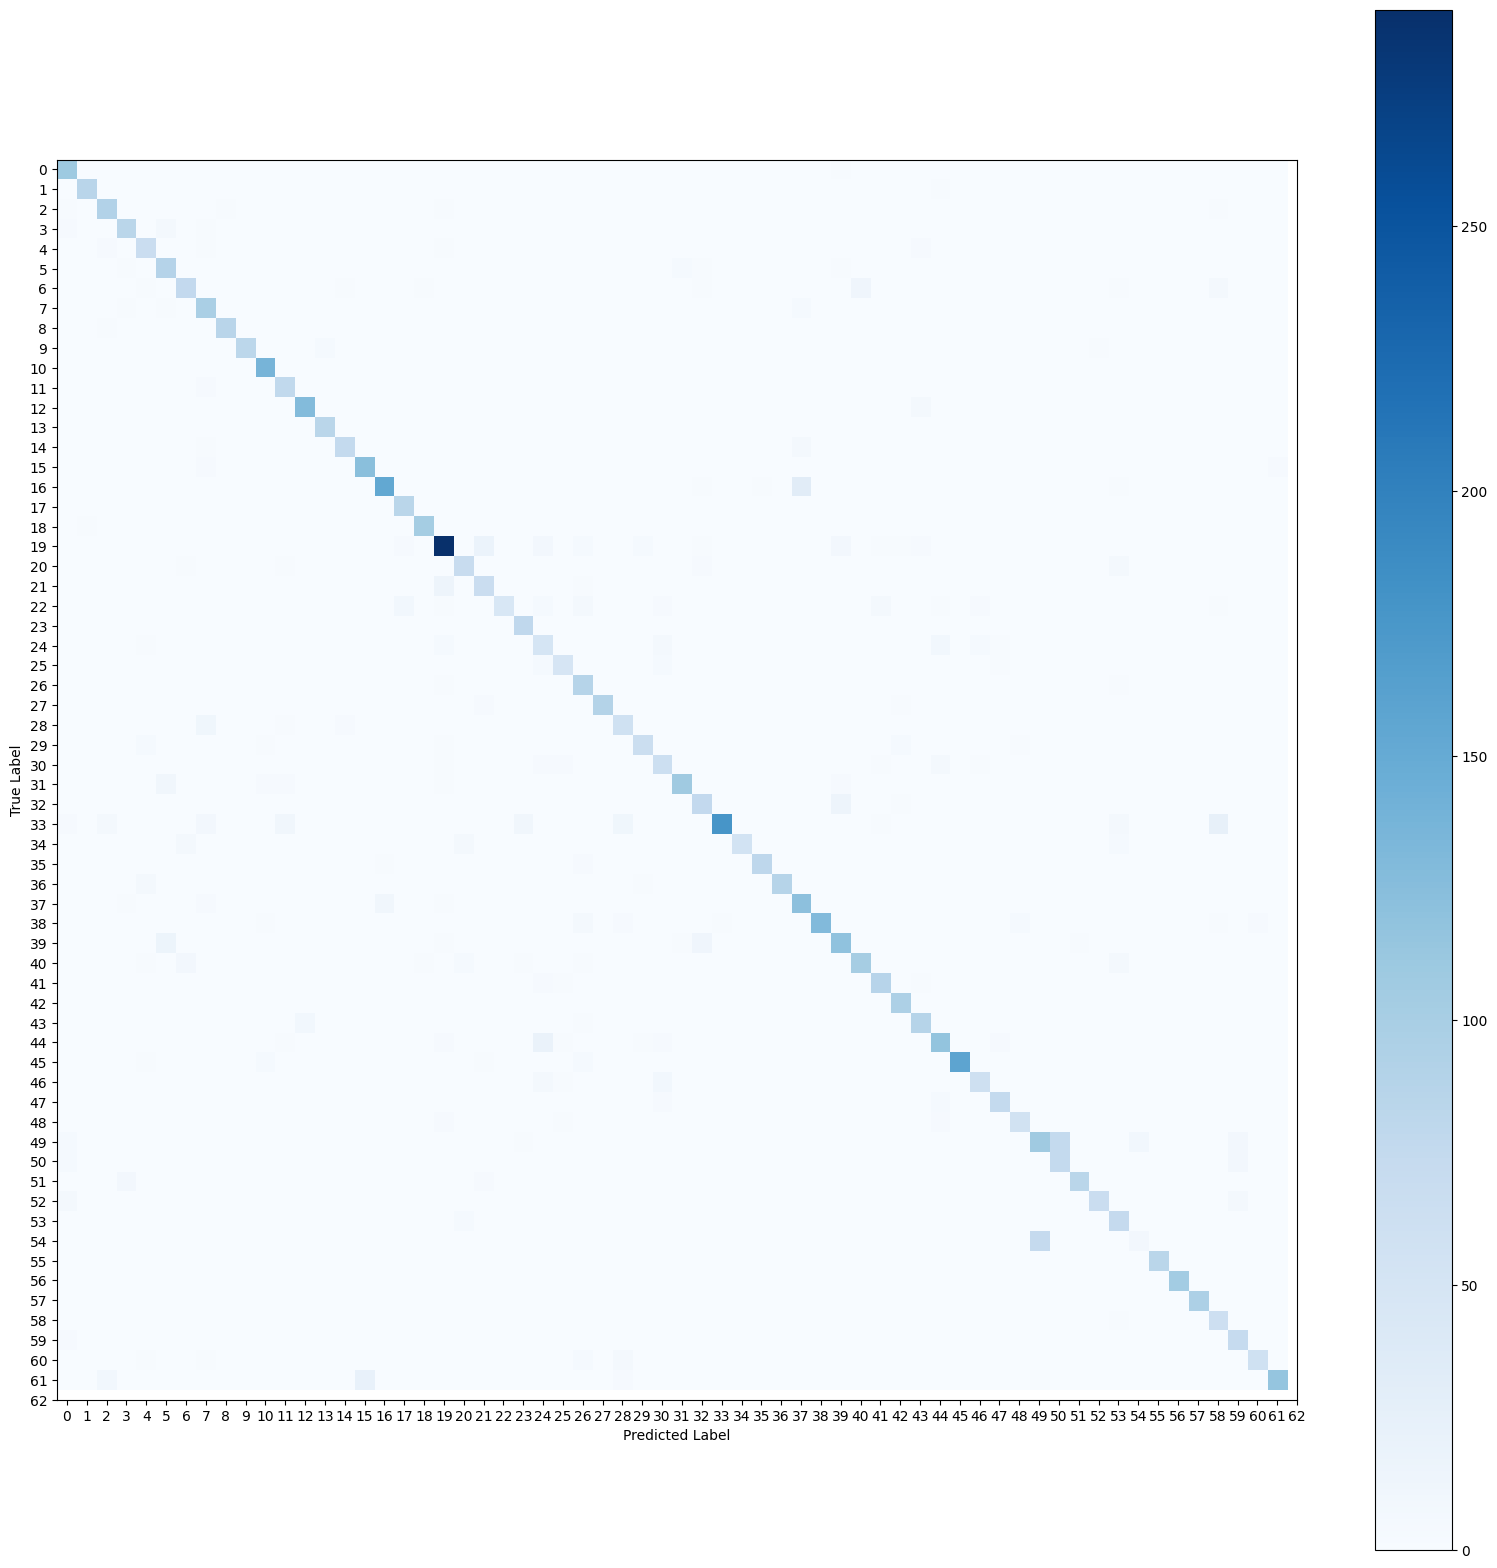

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

print(len(true_labels))

y_true = np.array(true_label)
y_pred = np.array(predicted_label)

y_true, y_pred
# convert numpy arrays to PyTorch tensors
y_true_t = tf.cast(y_true, dtype='float32')
y_pred_t = tf.cast(y_pred, dtype='float32')


# compute confusion matrix
cm = confusion_matrix(y_true_t, y_pred)

# plot confusion matrix
plt.figure(figsize=(20,20))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar()
plt.xticks(np.arange(63))
plt.yticks(np.arange(63))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
 from tensorflow.keras.models import load_model

# Define the path to your saved model
keras_file = 'model_second_vgg16.h5'

# Load the model
model_vgg16 = load_model(keras_file)
